In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

sns.set_theme(style="whitegrid", context="notebook")

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")



Rows: 20,640
Columns:9
Data Types
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

 Missing Vallues
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

 Duplicate rows
0


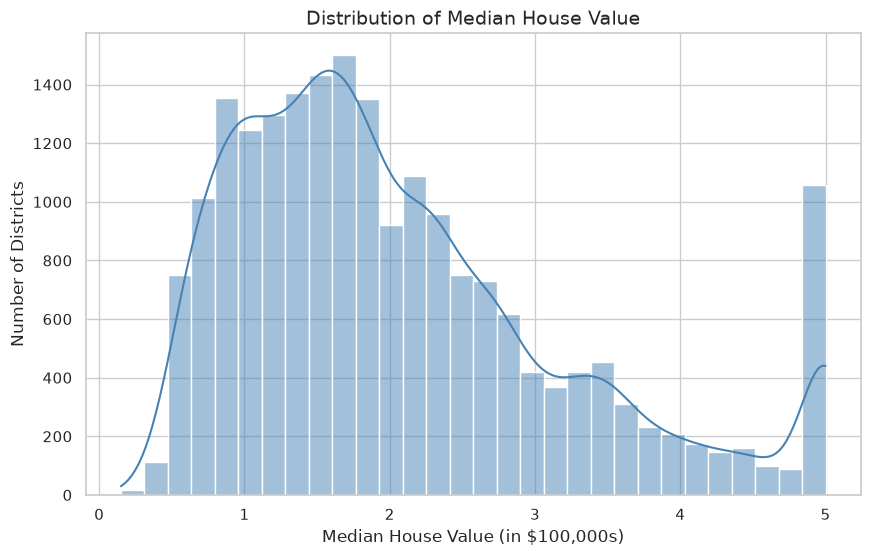

In [5]:
housing = fetch_california_housing(as_frame=True)
data = housing.frame.copy()

print(f"Rows: {data.shape[0]:,}")
print(f"Columns:{data.shape[1]:,}")

print("Data Types")
print(data.dtypes)

print("\n Missing Vallues")
print(data.isna().sum())

print("\n Duplicate rows")
print(data.duplicated().sum())

plt.figure(figsize=(10, 6))
sns.histplot(data['MedHouseVal'], bins=30, kde=True, color='steelblue')

plt.title("Distribution of Median House Value", fontsize=14)
plt.xlabel("Median House Value (in $100,000s)")
plt.ylabel("Number of Districts")

plt.show()

In [10]:
data.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

In [8]:
correlation = data.corr(numeric_only=True)['MedHouseVal'].sort_values(ascending=False)
print(correlation)

MedHouseVal    1.00
MedInc         0.69
AveRooms       0.15
HouseAge       0.11
AveOccup      -0.02
Population    -0.02
Longitude     -0.05
AveBedrms     -0.05
Latitude      -0.14
Name: MedHouseVal, dtype: float64


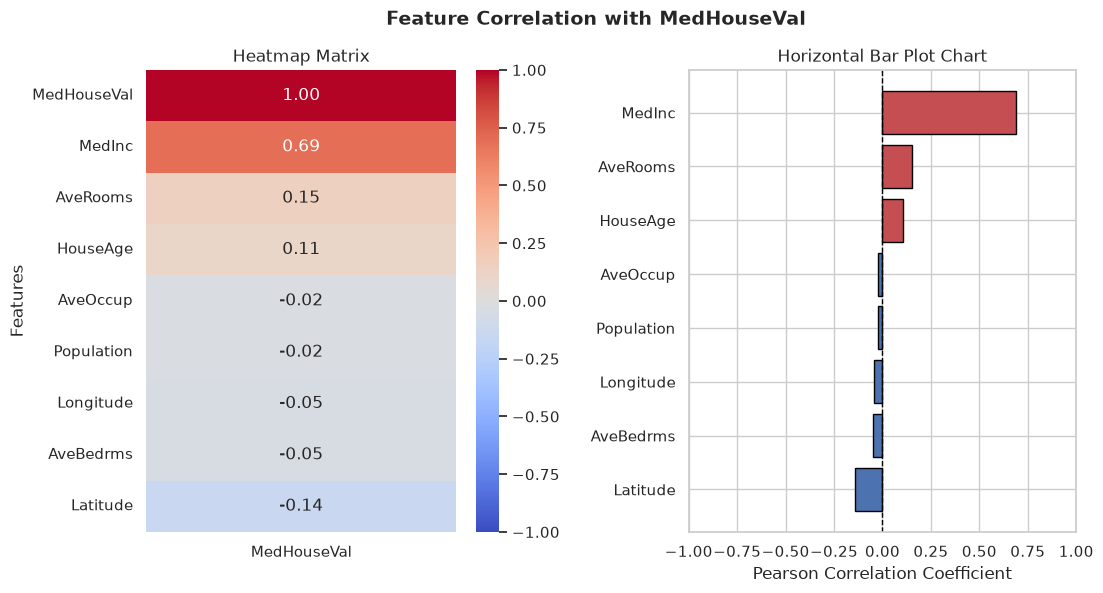

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


corr_matrix = data.corr()

target_corr = corr_matrix["MedHouseVal"].drop("MedHouseVal").sort_values()
heatmap_data = corr_matrix[["MedHouseVal"]].sort_values(
    by="MedHouseVal", ascending=False
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
plt.subplots_adjust(wspace=0.4)

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    cbar=True,
    ax=ax1,
)
ax1.set_title("Heatmap Matrix")
ax1.set_ylabel("Features")

colors = ["#4C72B0" if val < 0 else "#C44E52" for val in target_corr.values]

ax2.barh(target_corr.index, target_corr.values, color=colors, edgecolor="black")
ax2.axvline(
    0, color="black", linestyle="--", linewidth=1
)  
ax2.set_xlim(-1, 1)
ax2.set_title("Horizontal Bar Plot Chart")
ax2.set_xlabel("Pearson Correlation Coefficient")

plt.suptitle("Feature Correlation with MedHouseVal", fontsize=14, weight="bold")
plt.show()